# 04 — Final 3-Way Comparison

Single-omics vs. naive concatenation vs. MOFA factors, same models/folds/metrics.

In [1]:
import os
# working directory: run this notebook from the MLPipeline folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import common_utils as cu


In [2]:
experiments = {
    "Single-omics": cu.load_results("expression"),
    "Concatenated": cu.load_results("concatenated"),
    "MOFA": cu.load_results("mofa"),
}
models = ["coxnet", "rsf"]


## Summary table

In [3]:
rows = []
for exp_name, res in experiments.items():
    for model in models:
        c = res[model]["c_index"]
        b = res[model]["ibs"]
        rows.append({
            "experiment": exp_name,
            "model": model,
            "c_index_mean": np.mean(c),
            "c_index_std": np.std(c),
            "ibs_mean": np.nanmean(b),
            "ibs_std": np.nanstd(b),
            "ibs_valid_folds": int(np.sum(~np.isnan(b))),
        })

summary = pd.DataFrame(rows)
summary.to_csv("final_comparison_summary.csv", index=False)
summary


,experiment,model,c_index_mean,c_index_std,ibs_mean,ibs_std,ibs_valid_folds
0,Single-omics,coxnet,0.677559,0.069205,0.204867,0.043557,4
1,Single-omics,rsf,0.725133,0.079595,0.147951,0.011580,5
2,Concatenated,coxnet,0.670151,0.051961,0.209939,0.025936,2
3,Concatenated,rsf,0.738355,0.060788,0.148439,0.011407,5
4,MOFA,coxnet,0.680442,0.046122,0.169142,0.003966,5
5,MOFA,rsf,0.708363,0.074740,0.154802,0.012415,5


## C-index comparison, grouped by experiment

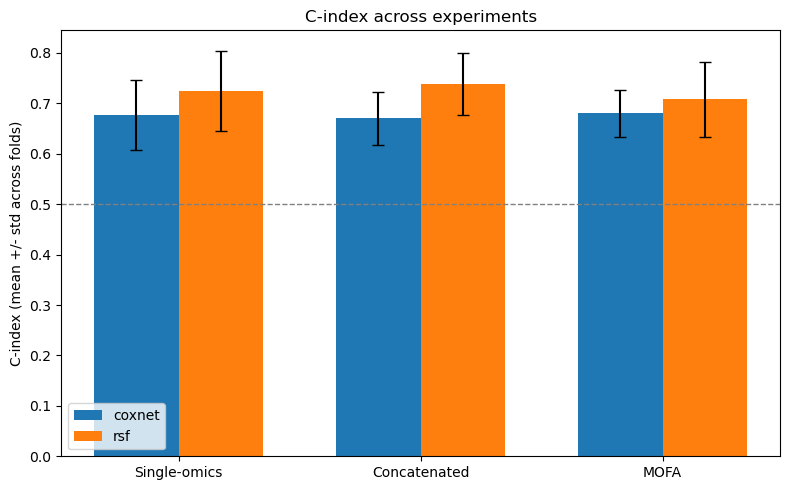

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

positions = np.arange(len(experiments))
width = 0.35

for i, model in enumerate(models):
    means = [np.mean(experiments[e][model]["c_index"]) for e in experiments]
    stds = [np.std(experiments[e][model]["c_index"]) for e in experiments]
    ax.bar(positions + i * width, means, width, yerr=stds, label=model, capsize=4)

ax.set_xticks(positions + width / 2)
ax.set_xticklabels(experiments.keys())
ax.set_ylabel("C-index (mean +/- std across folds)")
ax.set_title("C-index across experiments")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.legend()
plt.tight_layout()
plt.savefig("final_cindex_comparison.png", dpi=150)
plt.show()


## IBS comparison, grouped by experiment

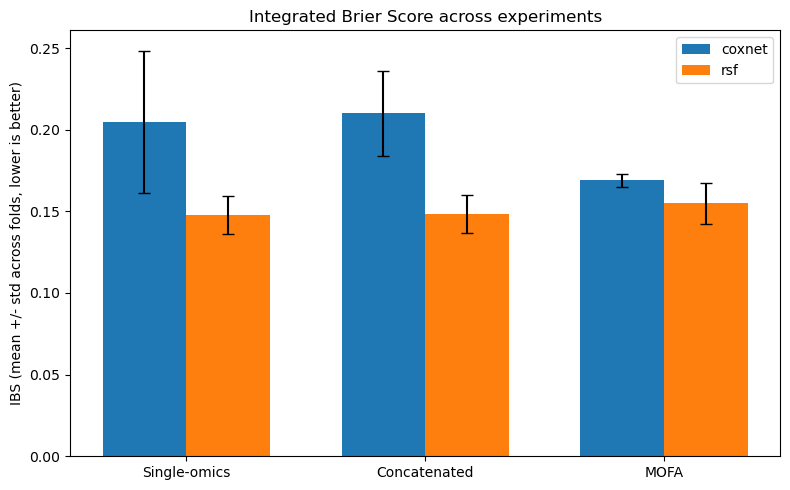

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(models):
    means = [np.nanmean(experiments[e][model]["ibs"]) for e in experiments]
    stds = [np.nanstd(experiments[e][model]["ibs"]) for e in experiments]
    ax.bar(positions + i * width, means, width, yerr=stds, label=model, capsize=4)

ax.set_xticks(positions + width / 2)
ax.set_xticklabels(experiments.keys())
ax.set_ylabel("IBS (mean +/- std across folds, lower is better)")
ax.set_title("Integrated Brier Score across experiments")
ax.legend()
plt.tight_layout()
plt.savefig("final_ibs_comparison.png", dpi=150)
plt.show()


## Dynamic AUC curves, RSF only (cleanest single-model view)

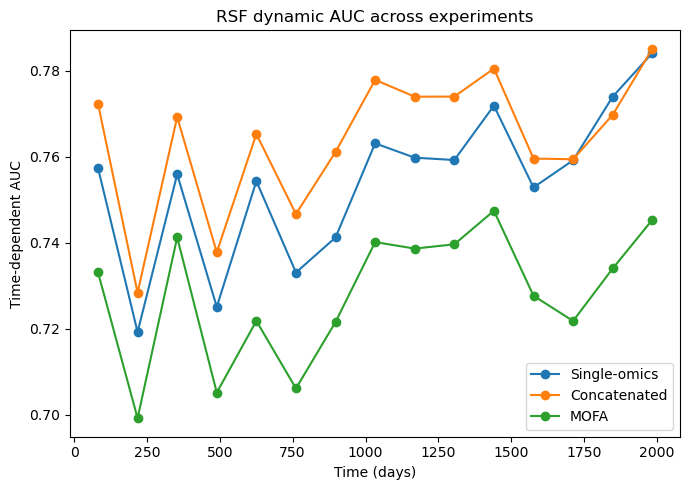

In [6]:
plt.figure(figsize=(7, 5))

for exp_name, res in experiments.items():
    eval_times = res["_eval_times"]
    mean_auc = np.nanmean(res["rsf"]["auc_curves"], axis=0)
    plt.plot(eval_times, mean_auc, marker="o", label=exp_name)

plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.title("RSF dynamic AUC across experiments")
plt.legend()
plt.tight_layout()
plt.savefig("final_auc_comparison_rsf.png", dpi=150)
plt.show()


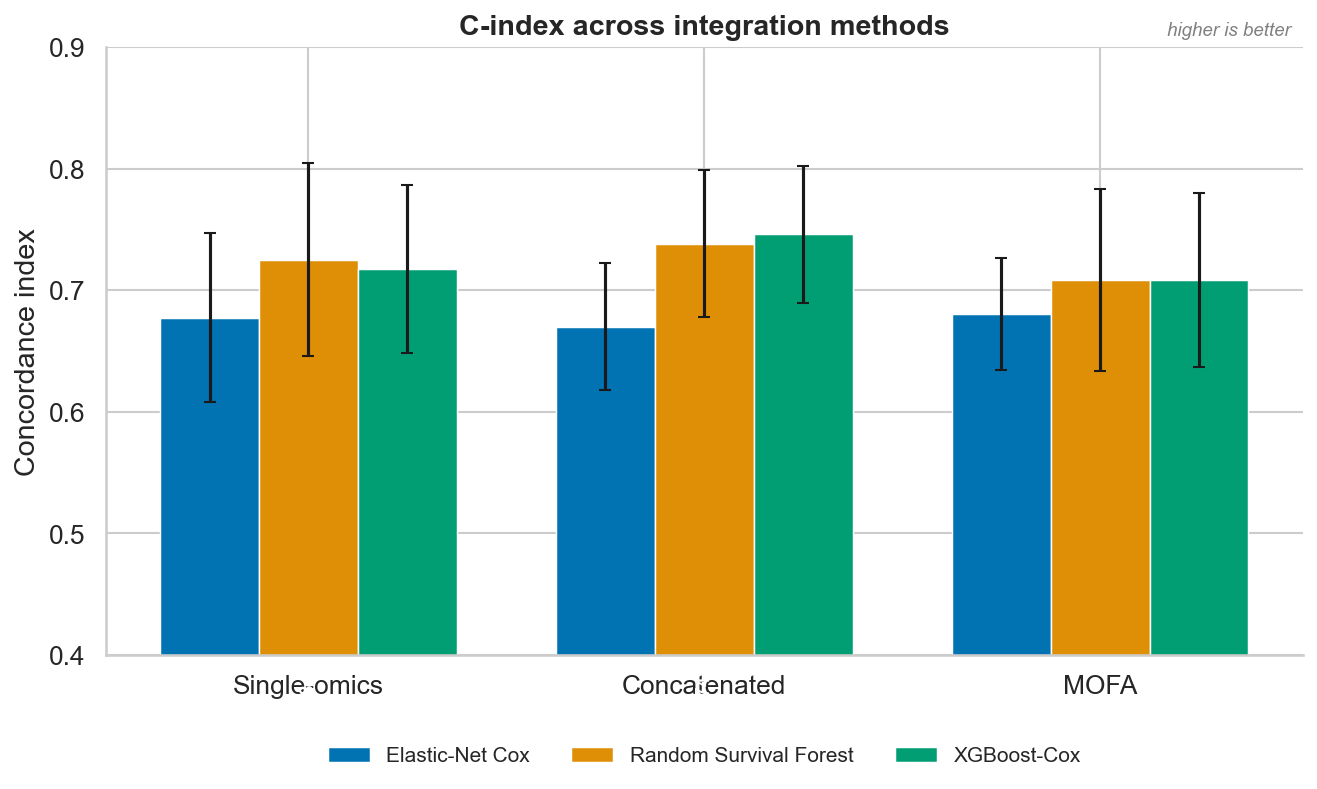

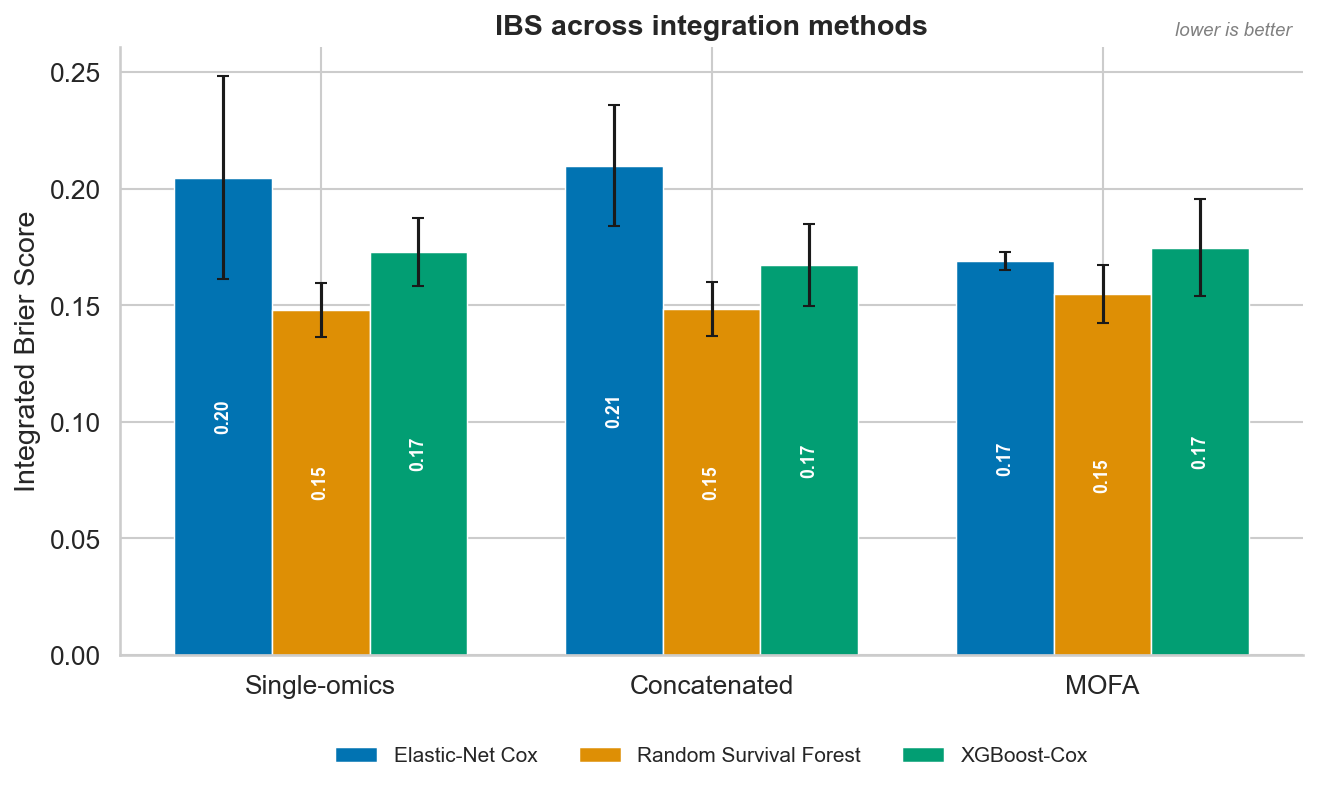

In [14]:
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.15)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"

experiments = {
    "Single-omics": cu.load_results("expression"),
    "Concatenated": cu.load_results("concatenated"),
    "MOFA": cu.load_results("mofa"),
}
models = ["coxnet", "rsf", "xgboost"]
model_labels = {"coxnet": "Elastic-Net Cox", "rsf": "Random Survival Forest", "xgboost": "XGBoost-Cox"}

positions = np.arange(len(experiments))
width = 0.25
offsets = [-width, 0, width]

def grouped_bar(metric_key, ylabel, title, better_note, nan_aware, fname, ylim=None):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for off, model in zip(offsets, models):
        if nan_aware:
            means = [np.nanmean(experiments[e][model][metric_key]) for e in experiments]
            stds = [np.nanstd(experiments[e][model][metric_key]) for e in experiments]
        else:
            means = [np.mean(experiments[e][model][metric_key]) for e in experiments]
            stds = [np.std(experiments[e][model][metric_key]) for e in experiments]
        bars = ax.bar(positions + off, means, width, yerr=stds, capsize=3,
                       label=model_labels[model], edgecolor="white", linewidth=0.7, zorder=2)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                    f"{m:.2f}", ha="center", va="center", fontsize=8.5, fontweight="bold",
                    color="white", rotation=90, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(experiments.keys())
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim:
        ax.set_ylim(*ylim)
    ax.text(0.99, 1.02, better_note, transform=ax.transAxes, ha="right", fontsize=9,
            style="italic", color="gray")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=10)
    sns.despine()
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

grouped_bar("c_index", "Concordance index", "C-index across integration methods",
            "higher is better", nan_aware=False, fname="results_cindex_grouped.png", ylim=(0.4, 0.9))

grouped_bar("ibs", "Integrated Brier Score", "IBS across integration methods",
            "lower is better", nan_aware=True, fname="results_ibs_grouped.png")

## Dynamic AUC curves, Coxnet only

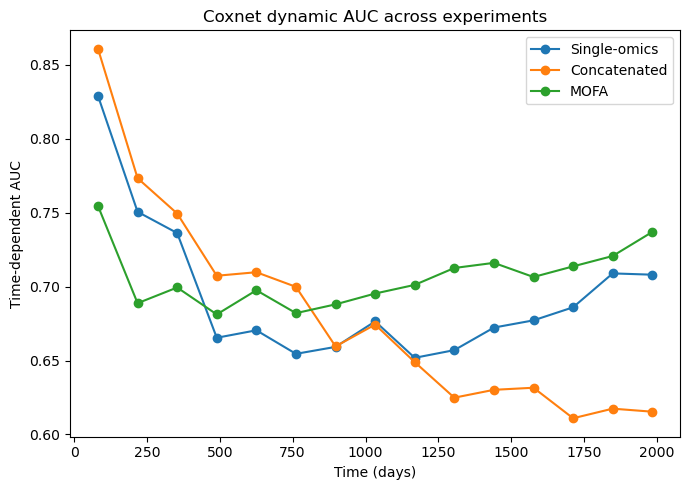

In [7]:
plt.figure(figsize=(7, 5))

for exp_name, res in experiments.items():
    eval_times = res["_eval_times"]
    mean_auc = np.nanmean(res["coxnet"]["auc_curves"], axis=0)
    plt.plot(eval_times, mean_auc, marker="o", label=exp_name)

plt.xlabel("Time (days)")
plt.ylabel("Time-dependent AUC")
plt.title("Coxnet dynamic AUC across experiments")
plt.legend()
plt.tight_layout()
plt.savefig("final_auc_comparison_coxnet.png", dpi=150)
plt.show()


### IBS, restyled with fold-count annotations

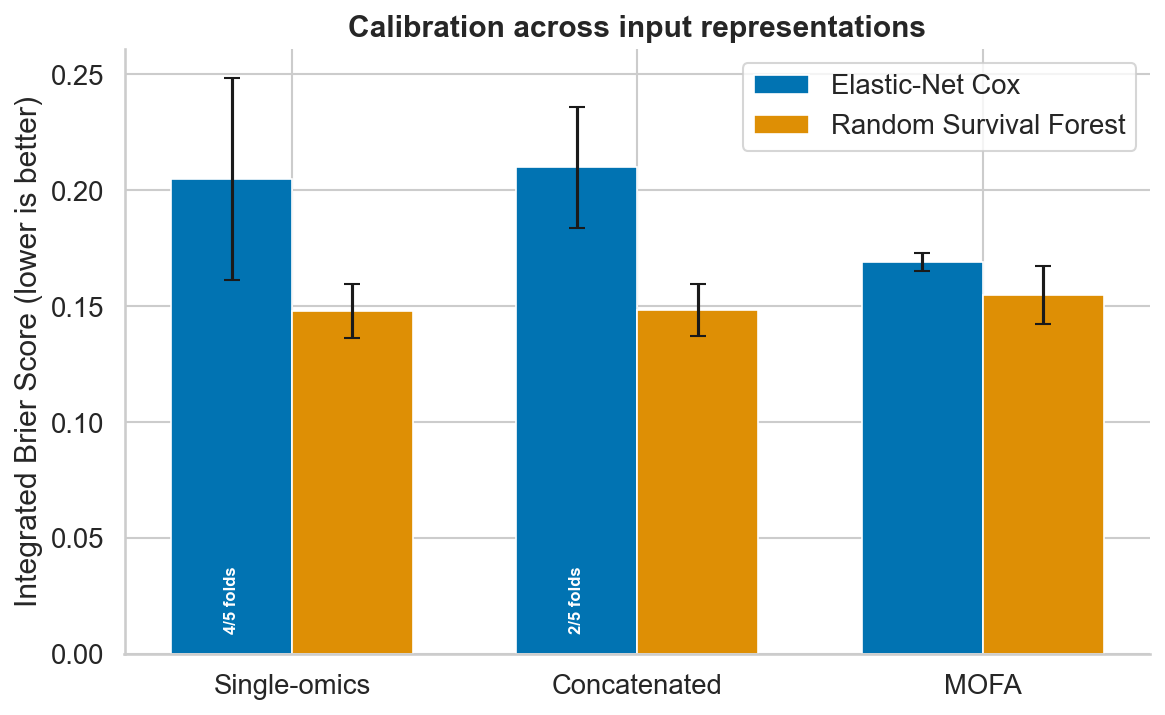

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(models):
    means = [np.nanmean(experiments[e][model]["ibs"]) for e in experiments]
    stds = [np.nanstd(experiments[e][model]["ibs"]) for e in experiments]
    bars = ax.bar(positions + i * width, means, width, yerr=stds, capsize=4,
                   label=model_labels[model], edgecolor="white", linewidth=0.8)
    for j, (bar, exp_name) in enumerate(zip(bars, experiments)):
        n_valid = np.sum(~np.isnan(experiments[exp_name][model]["ibs"]))
        note = f"{n_valid}/5 folds" if n_valid < 5 else ""
        if note:
            ax.text(bar.get_x() + bar.get_width()/2, 0.01, note,
                    ha="center", fontsize=8, color="white", rotation=90, fontweight="bold")

ax.set_xticks(positions + width / 2)
ax.set_xticklabels(experiments.keys())
ax.set_ylabel("Integrated Brier Score (lower is better)")
ax.set_title("Calibration across input representations")
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("pretty_ibs_comparison.png", dpi=300)
plt.show()


### Kaplan-Meier risk-group stratification (new)

For each experiment, patients are split at the median predicted risk score (RSF) into high/low risk groups. This is used as an extra visualisation for the C-Index, not a statistical measure (since splitting high-risk from low-risk at median is not necessarily the best way)

Loaded 318 samples x 5000 features, 5 folds.


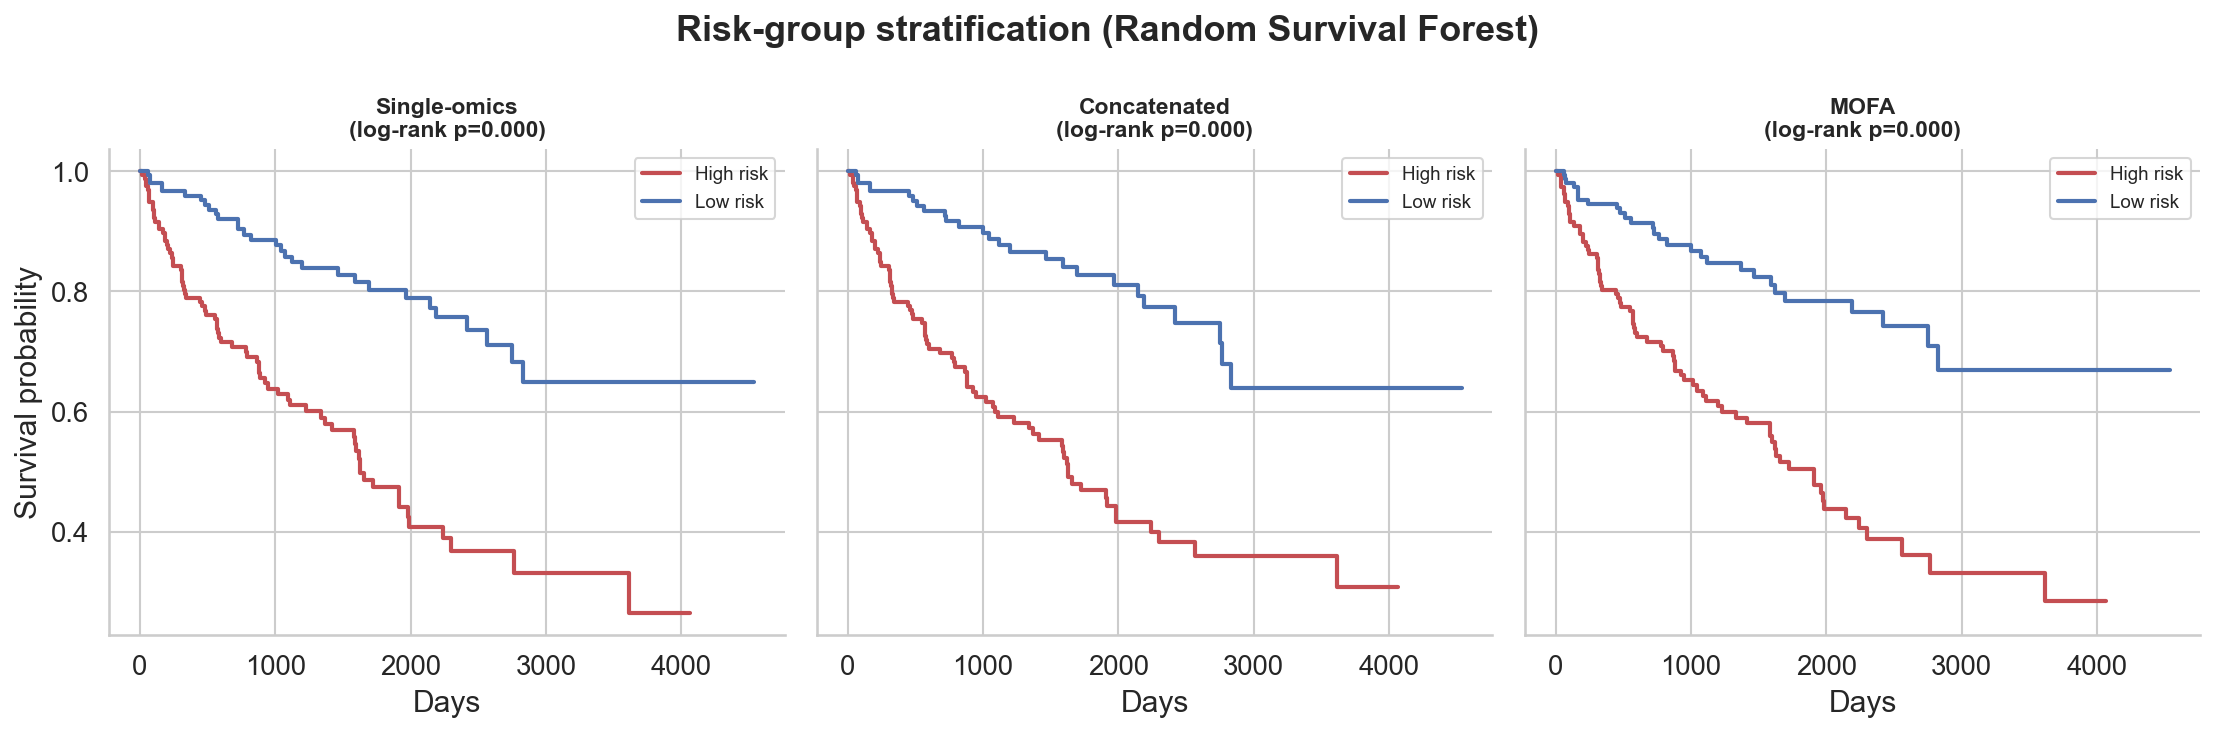

In [11]:
cu.CONFIG["debug_mode"] = False
X_ref, y, fold_arr, samples, feature_names = cu.load_reference_cohort(feature_file="preprocessed_multiomics/expression_filtered.csv")
event_field, time_field = y.dtype.names

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (exp_name, res) in zip(axes, experiments.items()):
    risk = res["rsf"]["risk_oof"]
    high_risk = risk >= np.median(risk)

    for group_mask, label, color in [(high_risk, "High risk", "#C44E52"), (~high_risk, "Low risk", "#4C72B0")]:
        t, surv_prob = kaplan_meier_estimator(y[event_field][group_mask], y[time_field][group_mask])
        ax.step(t, surv_prob, where="post", label=label, color=color, linewidth=2)

    chisq, pval = compare_survival(y, high_risk.astype(int))
    ax.set_title(f"{exp_name}\n(log-rank p={pval:.3f})", fontsize=11)
    ax.set_xlabel("Days")
    if ax is axes[0]:
        ax.set_ylabel("Survival probability")
    ax.legend(fontsize=9)

fig.suptitle("Risk-group stratification (Random Survival Forest)", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("pretty_km_stratification.png", dpi=300)
plt.show()
